# Feature Engineering — Demanda Horaria ZMVM

Este notebook construye el dataset de features para el **modelo predictivo de demanda eléctrica horaria** en la ZMVM (Línea 1 del plan de modelado).

El proceso integra las cuatro fuentes de datos del EDA en un único DataFrame indexado por hora, aplica el tratamiento definido para cada grupo de variables, y exporta dos datasets segmentados por el quiebre estructural de 2020:

- `features_2016_2019.parquet` — área CEN original
- `features_2020_2024.parquet` — área CEN ampliada post-reclasificación

Ver `docs/plan_modelado.md` para el contexto y justificación de las decisiones tomadas.

### Carga de librerías

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

RAW_DIR       = Path("..") / "data" / "raw"
PROCESSED_DIR = Path("..") / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## 1. Carga de datos

In [19]:
df_demanda  = pd.read_parquet(RAW_DIR / "demanda_real_combined.parquet")
df_clima    = pd.read_parquet(RAW_DIR / "clima_zmvm_combined.parquet")
df_economia = pd.read_parquet(RAW_DIR / "economia_combined.parquet")

print("Demanda: ", df_demanda.shape)
print("Clima:   ", df_clima.shape)
print("Economía:", df_economia.shape)

Demanda:  (3151218, 10)
Clima:    (230184, 12)
Economía: (108, 5)


## 2. Demanda CEN — Preparación

Se filtra el área CEN, se eliminan registros con hora > 24 (31 registros inválidos identificados en el EDA), y se agregan los registros duplicados por (fecha, hora) tomando la media. Finalmente se construye un datetime estándar: CENACE usa convención hora 1–24, donde hora=1 corresponde a 00:00–01:00.

In [20]:
df_cen = (
    df_demanda[df_demanda["area"] == "CEN"]
    [["fecha", "hora", "demanda_balance_mwh"]]
    .query("hora <= 24")
    .groupby(["fecha", "hora"], as_index=False)["demanda_balance_mwh"]
    .mean()
)

# Hora 1-24 → datetime estándar (hora 1 = 00:00)
df_cen["datetime"] = (
    pd.to_datetime(df_cen["fecha"]) +
    pd.to_timedelta(df_cen["hora"] - 1, unit="h")
)
df_cen = df_cen.set_index("datetime").sort_index()

print(f"Registros: {len(df_cen):,}")
print(f"Rango:     {df_cen.index.min()} → {df_cen.index.max()}")
df_cen.head()

Registros: 76,721
Rango:     2016-04-01 00:00:00 → 2024-12-31 23:00:00


,fecha,hora,demanda_balance_mwh
datetime,,,
2016-04-01 00:00:00,2016-04-01,1,4775.122000
2016-04-01 01:00:00,2016-04-01,2,4648.743667
2016-04-01 02:00:00,2016-04-01,3,4660.170667
2016-04-01 03:00:00,2016-04-01,4,4655.247333
2016-04-01 04:00:00,2016-04-01,5,4678.285333


## 3. Clima — Promedio ponderado

Se construye una variable climática representativa de la ZMVM usando un **promedio ponderado** de las tres estaciones, con pesos que reflejan su contribución relativa al consumo del área CEN:

| Estación | Peso | Justificación |
|---|---|---|
| CDMX | 50% | Mayor concentración de población y consumo comercial/residencial |
| Pachuca | 30% | Corredor norte, zona industrial (Tula, Hidalgo) |
| Toluca | 20% | Poniente ZMVM, menor peso en área CEN |

Variables resultantes: `temperatura`, `humedad`, `radiacion`.

In [21]:
PESOS = {
    "cdmx_aeropuerto": 0.50,
    "pachuca":         0.30,
    "toluca":          0.20,
}

df_clima_idx = df_clima.set_index("datetime") if "datetime" in df_clima.columns else df_clima

vars_clima = ["temperature_2m", "relative_humidity_2m", "shortwave_radiation"]

frames = []
for station_id, peso in PESOS.items():
    sub = (
        df_clima_idx[df_clima_idx["station_id"] == station_id][vars_clima]
        .multiply(peso)
    )
    frames.append(sub)

df_clima_pond = sum(frames)
df_clima_pond.columns = ["temperatura", "humedad", "radiacion"]

print(f"Registros clima: {len(df_clima_pond):,}")
print(f"Rango:           {df_clima_pond.index.min()} → {df_clima_pond.index.max()}")
df_clima_pond.head()

Registros clima: 76,728
Rango:           2016-04-01 00:00:00 → 2024-12-31 23:00:00


,temperatura,humedad,radiacion
datetime,,,
2016-04-01 00:00:00,13.80,49.9,0.0
2016-04-01 01:00:00,13.01,53.2,0.0
2016-04-01 02:00:00,12.31,55.2,0.0
2016-04-01 03:00:00,11.67,56.5,0.0
2016-04-01 04:00:00,11.15,58.0,0.0


## 4. Merge al nivel horario

In [22]:
df = df_cen[["demanda_balance_mwh"]].join(df_clima_pond, how="inner")

print(f"Registros tras merge: {len(df):,}")
print(f"Rango:                {df.index.min()} → {df.index.max()}")
print(f"Nulos:\n{df.isnull().sum()}")
df.head()

Registros tras merge: 76,721
Rango:                2016-04-01 00:00:00 → 2024-12-31 23:00:00
Nulos:
demanda_balance_mwh    0
temperatura            0
humedad                0
radiacion              0
dtype: int64


,demanda_balance_mwh,temperatura,humedad,radiacion
datetime,,,,
2016-04-01 00:00:00,4775.122000,13.80,49.9,0.0
2016-04-01 01:00:00,4648.743667,13.01,53.2,0.0
2016-04-01 02:00:00,4660.170667,12.31,55.2,0.0
2016-04-01 03:00:00,4655.247333,11.67,56.5,0.0
2016-04-01 04:00:00,4678.285333,11.15,58.0,0.0


## 5. Variables temporales

Se construyen variables que capturan los patrones cíclicos de la demanda: hora del día, día de semana, mes, estación del año y un indicador de día hábil vs festivo/fin de semana.

Para los días festivos oficiales de México se usa la librería `holidays` con el calendario federal (`country="MX"`), que incluye los días de descanso obligatorio según la Ley Federal del Trabajo.

In [23]:
try:
    import holidays as hol
    mx_holidays = set(hol.Mexico(years=range(2016, 2025)).keys())
except ImportError:
    # Días festivos oficiales México (Ley Federal del Trabajo) — fallback manual
    mx_holidays = set()
    for yr in range(2016, 2025):
        mx_holidays.update([
            pd.Timestamp(f"{yr}-01-01"),  # Año Nuevo
            pd.Timestamp(f"{yr}-02-05"),  # Constitución
            pd.Timestamp(f"{yr}-03-21"),  # Natalicio Juárez
            pd.Timestamp(f"{yr}-05-01"),  # Día del Trabajo
            pd.Timestamp(f"{yr}-09-16"),  # Independencia
            pd.Timestamp(f"{yr}-11-20"),  # Revolución
            pd.Timestamp(f"{yr}-12-25"),  # Navidad
        ])

def get_estacion(mes):
    if mes in [3, 4, 5]:   return "primavera"
    elif mes in [6, 7, 8]: return "verano"
    elif mes in [9, 10, 11]: return "otoño"
    else:                   return "invierno"

df["hora"]       = df.index.hour
df["dia_semana"] = df.index.dayofweek          # 0=lunes, 6=domingo
df["mes"]        = df.index.month
df["estacion"]   = df["mes"].map(get_estacion)
df["es_festivo"] = df.index.normalize().isin(mx_holidays).astype(int)
df["es_fin_semana"] = (df["dia_semana"] >= 5).astype(int)
df["dia_no_laboral"] = ((df["es_fin_semana"] == 1) | (df["es_festivo"] == 1)).astype(int)

print("Variables temporales agregadas:")
print(df[["hora","dia_semana","mes","estacion","es_festivo","dia_no_laboral"]].head(10))

Variables temporales agregadas:
                     hora  dia_semana  mes   estacion  es_festivo  \
datetime                                                            
2016-04-01 00:00:00     0           4    4  primavera           0   
2016-04-01 01:00:00     1           4    4  primavera           0   
2016-04-01 02:00:00     2           4    4  primavera           0   
2016-04-01 03:00:00     3           4    4  primavera           0   
2016-04-01 04:00:00     4           4    4  primavera           0   
2016-04-01 05:00:00     5           4    4  primavera           0   
2016-04-01 06:00:00     6           4    4  primavera           0   
2016-04-01 07:00:00     7           4    4  primavera           0   
2016-04-01 08:00:00     8           4    4  primavera           0   
2016-04-01 09:00:00     9           4    4  primavera           0   

                     dia_no_laboral  
datetime                             
2016-04-01 00:00:00               0  
2016-04-01 01:00:00      

## 6. Variables climáticas — Rezagos

La respuesta de la demanda al clima no es instantánea: el aire acondicionado o calefacción tarda en reflejarse en el consumo eléctrico. Se agregan rezagos de temperatura de 1 y 2 horas.

In [24]:
df["temperatura_lag1h"] = df["temperatura"].shift(1)
df["temperatura_lag2h"] = df["temperatura"].shift(2)

print("Variables climáticas disponibles:")
print([c for c in df.columns if c in ["temperatura","humedad","radiacion","temperatura_lag1h","temperatura_lag2h"]])

Variables climáticas disponibles:
['temperatura', 'humedad', 'radiacion', 'temperatura_lag1h', 'temperatura_lag2h']


## 7. Variables de rezago de demanda

Los lags de demanda son los predictores más fuertes en series de energía — capturan la memoria del sistema:

- `demanda_lag_1h` — demanda de la hora inmediatamente anterior
- `demanda_lag_24h` — demanda a la misma hora del día anterior (patrón diario)
- `demanda_lag_168h` — demanda a la misma hora de la semana anterior (patrón semanal)

In [25]:
df["demanda_lag_1h"]   = df["demanda_balance_mwh"].shift(1)
df["demanda_lag_24h"]  = df["demanda_balance_mwh"].shift(24)
df["demanda_lag_168h"] = df["demanda_balance_mwh"].shift(168)

print("Nulos introducidos por lags:")
lag_cols = ["demanda_lag_1h", "demanda_lag_24h", "demanda_lag_168h"]
print(df[lag_cols].isnull().sum())

Nulos introducidos por lags:
demanda_lag_1h        1
demanda_lag_24h      24
demanda_lag_168h    168
dtype: int64


## 8. Variables económicas

IGAE e IMAI son series mensuales. Se hace un merge por año-mes, repitiendo el mismo valor para cada hora dentro del mes. ITAEE se excluye por ser forward-fill desde 2021 (ver `docs/plan_modelado.md`).

In [26]:
df_eco = df_economia[["fecha", "igae_total", "imai_industrial"]].copy()
df_eco["año_mes"] = df_eco["fecha"].dt.to_period("M")

df["año_mes"] = df.index.to_period("M")
df = df.merge(
    df_eco[["año_mes", "igae_total", "imai_industrial"]],
    on="año_mes", how="left"
).set_index(df.index)
df = df.drop(columns="año_mes")

print("Nulos en variables económicas:")
print(df[["igae_total", "imai_industrial"]].isnull().sum())

Nulos en variables económicas:
igae_total         0
imai_industrial    0
dtype: int64


## 9. Segmentación por periodo

Se elimina la primera semana de datos (nulos por `lag_168h`) y se divide el dataset en los dos periodos definidos por el quiebre estructural de 2020.

In [27]:
df = df.dropna(subset=["demanda_lag_168h", "temperatura_lag2h"])

df["periodo"] = (df.index.year >= 2020).astype(int)

df_a = df[df["periodo"] == 0].copy()  # 2016-2019
df_b = df[df["periodo"] == 1].copy()  # 2020-2024

print(f"Periodo A (2016-2019): {len(df_a):,} registros | {df_a.index.min().date()} → {df_a.index.max().date()}")
print(f"Periodo B (2020-2024): {len(df_b):,} registros | {df_b.index.min().date()} → {df_b.index.max().date()}")
print(f"\nColumnas finales ({len(df.columns)}):")
print(list(df.columns))

Periodo A (2016-2019): 32,708 registros | 2016-04-08 → 2019-12-31
Periodo B (2020-2024): 43,845 registros | 2020-01-01 → 2024-12-31

Columnas finales (19):
['demanda_balance_mwh', 'temperatura', 'humedad', 'radiacion', 'hora', 'dia_semana', 'mes', 'estacion', 'es_festivo', 'es_fin_semana', 'dia_no_laboral', 'temperatura_lag1h', 'temperatura_lag2h', 'demanda_lag_1h', 'demanda_lag_24h', 'demanda_lag_168h', 'igae_total', 'imai_industrial', 'periodo']


## 10. Análisis de correlación

Heatmap de correlación entre todas las features numéricas y la variable objetivo `demanda_balance_mwh`, por periodo. Permite confirmar qué variables tienen señal real antes de pasarlas al modelo.

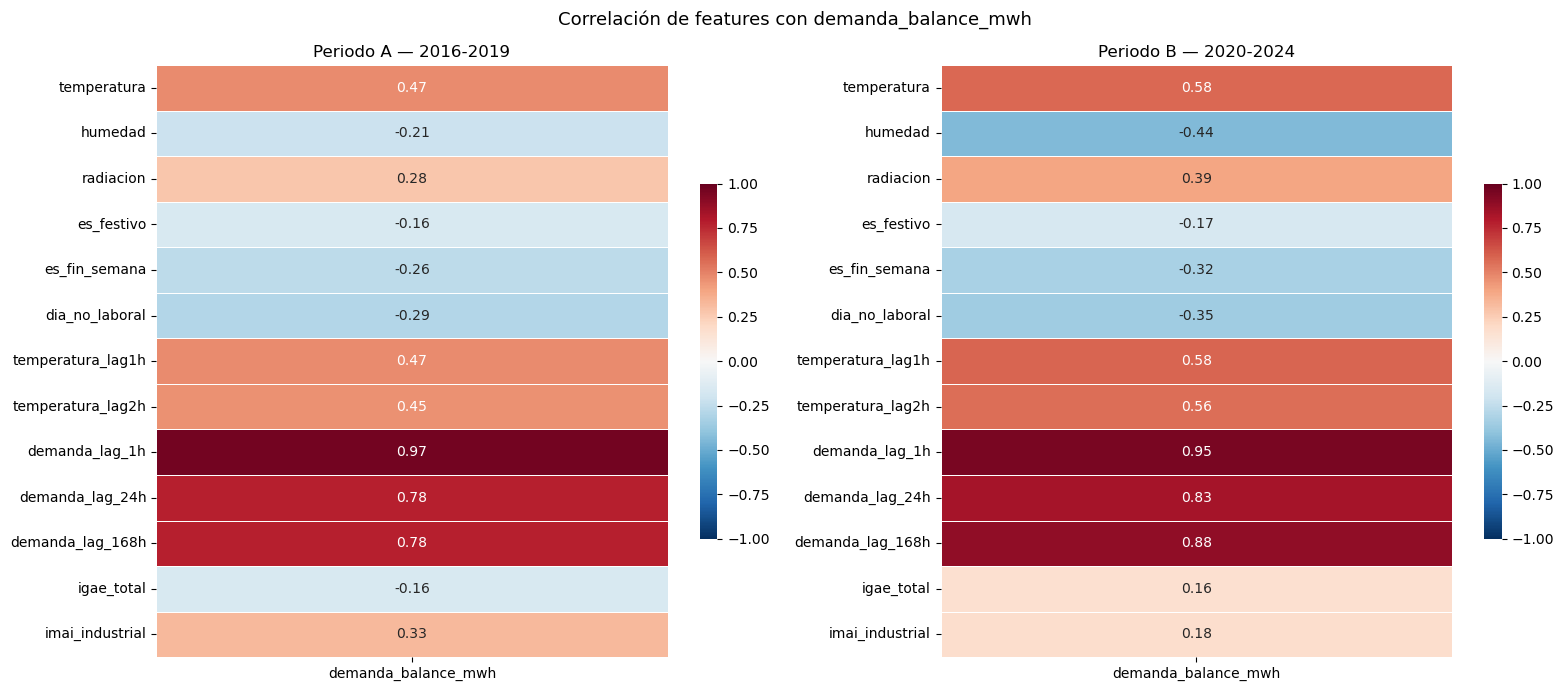

In [28]:
num_cols = [c for c in df.columns if df[c].dtype in [np.float64, np.int64, int, float]
            and c not in ["periodo"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (periodo_id, periodo_df, titulo) in zip(axes, [
    (0, df_a, "Periodo A — 2016-2019"),
    (1, df_b, "Periodo B — 2020-2024"),
]):
    corr = periodo_df[num_cols].corr()[["demanda_balance_mwh"]].drop("demanda_balance_mwh")
    sns.heatmap(
        corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
        vmin=-1, vmax=1, linewidths=0.4, ax=ax,
        cbar_kws={"shrink": 0.6}
    )
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.suptitle("Correlación de features con demanda_balance_mwh", fontsize=13)
plt.tight_layout()
plt.show()

## 10b. Autocorrelación — ACF y PACF

Se grafican la función de autocorrelación (ACF) y autocorrelación parcial (PACF) de la serie de demanda por periodo, con hasta 170 rezagos para capturar los tres ciclos clave: horario (lag 1), diario (lag 24) y semanal (lag 168).

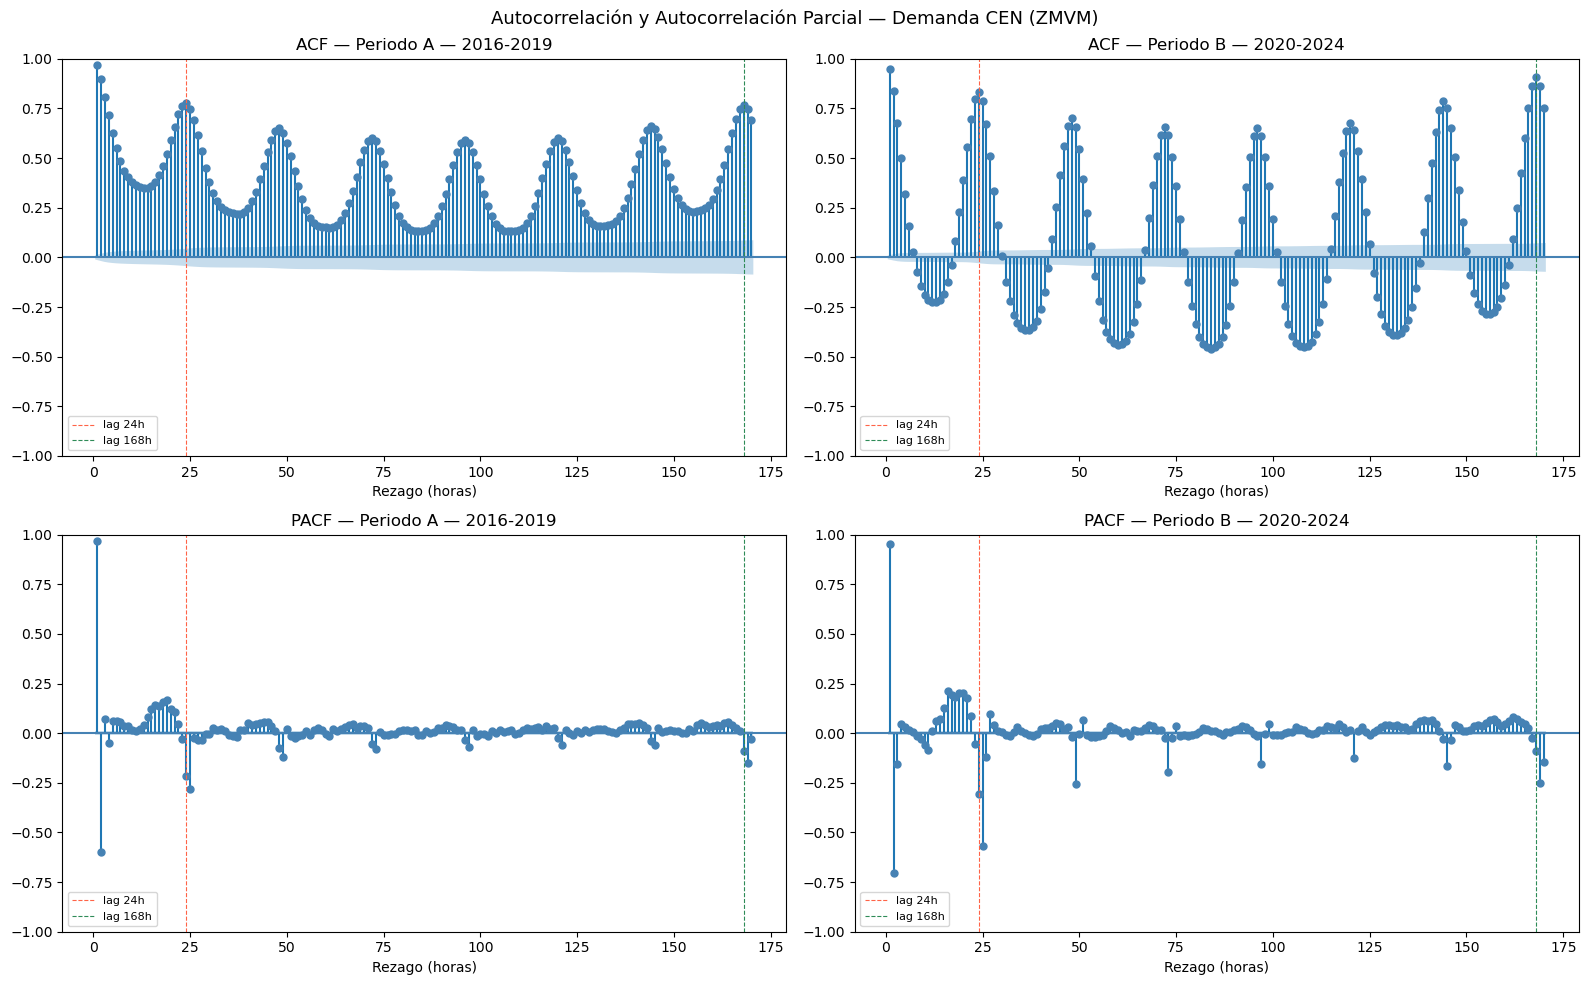

In [29]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for col, (serie, titulo) in enumerate([
    (df_a["demanda_balance_mwh"], "Periodo A — 2016-2019"),
    (df_b["demanda_balance_mwh"], "Periodo B — 2020-2024"),
]):
    plot_acf(serie.dropna(), lags=170, ax=axes[0, col],
             title=f"ACF — {titulo}", alpha=0.05, color="steelblue", zero=False)
    axes[0, col].axvline(24,  color="tomato",   linestyle="--", linewidth=0.8, label="lag 24h")
    axes[0, col].axvline(168, color="seagreen",  linestyle="--", linewidth=0.8, label="lag 168h")
    axes[0, col].legend(fontsize=8)
    axes[0, col].set_xlabel("Rezago (horas)")

    plot_pacf(serie.dropna(), lags=170, ax=axes[1, col],
              title=f"PACF — {titulo}", alpha=0.05, color="steelblue", zero=False, method="ywm")
    axes[1, col].axvline(24,  color="tomato",   linestyle="--", linewidth=0.8, label="lag 24h")
    axes[1, col].axvline(168, color="seagreen",  linestyle="--", linewidth=0.8, label="lag 168h")
    axes[1, col].legend(fontsize=8)
    axes[1, col].set_xlabel("Rezago (horas)")

plt.suptitle("Autocorrelación y Autocorrelación Parcial — Demanda CEN (ZMVM)", fontsize=13)
plt.tight_layout()
plt.show()

## 11. Exportación

In [30]:
df_a.to_parquet(PROCESSED_DIR / "features_2016_2019.parquet")
df_b.to_parquet(PROCESSED_DIR / "features_2020_2024.parquet")

print("Archivos exportados:")
for f in PROCESSED_DIR.iterdir():
    size_mb = f.stat().st_size / 1024**2
    print(f"  {f.name}  ({size_mb:.1f} MB)")

Archivos exportados:
  features_2020_2024.parquet  (2.5 MB)
  features_2016_2019.parquet  (1.8 MB)
